In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

In [10]:
df_raw = pd.read_csv('./dataset/LD2011_2014.txt', sep=';', decimal=',', header=None)

In [11]:
column_name = 'MT_002' if 'MT_002' in df_raw.columns else df_raw.columns[2]
load_data = pd.to_numeric(df_raw[column_name], errors='coerce')

In [12]:
timestamps = pd.date_range(start='2011-01-01 00:15:00', periods=len(df_raw), freq='15min')
load_data.index = timestamps

In [13]:
load_hourly = load_data.resample('h').mean()

In [14]:
valid_idx = load_hourly[load_hourly > 0].index
if len(valid_idx) > 0:
    load_hourly = load_hourly.loc[valid_idx[0]:]

In [15]:
load_hourly = load_hourly.replace(0, np.nan).ffill()

In [16]:
np.random.seed(42)
df = pd.DataFrame({
    "load": load_hourly,
    "temperature": 15 + 10*np.sin(np.arange(len(load_hourly))/24) + np.random.normal(0, 0.5, len(load_hourly)),
    "humidity": 50 + 20*np.random.rand(len(load_hourly)),
    "wind": 2 + np.random.normal(0, 0.2, len(load_hourly))
}, index=load_hourly.index)

In [17]:
df['hour'] = df.index.hour
df = df.dropna()

In [18]:
df.head()

,load,temperature,humidity,wind,hour
2012-01-01 00:00:00,11.379801,15.248357,66.765597,2.163980,0
2012-01-01 01:00:00,22.581792,15.347414,56.476666,2.058384,1
2012-01-01 02:00:00,23.648649,16.156213,69.542037,1.994773,2
2012-01-01 03:00:00,22.226174,17.008262,51.576277,1.980072,3
2012-01-01 04:00:00,22.048364,16.541885,64.496591,1.921633,4


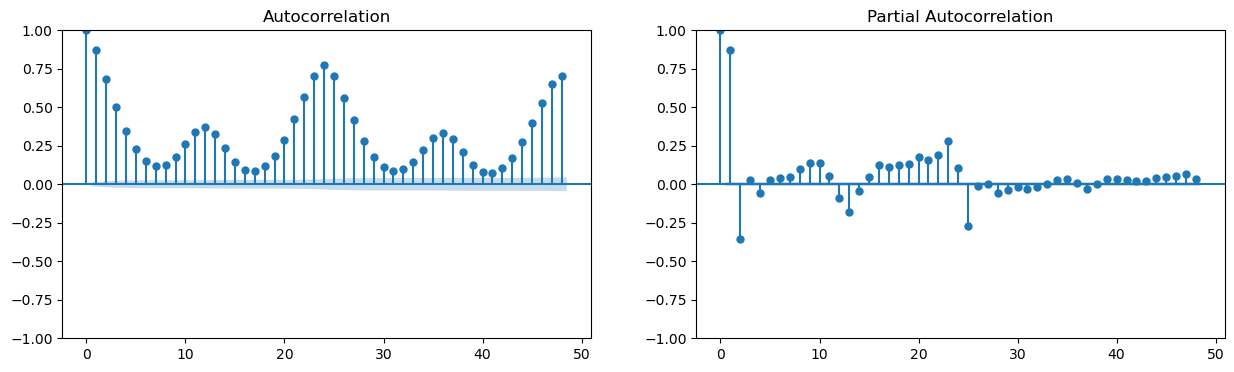

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(df['load'], lags=48, ax=ax[0])
plot_pacf(df['load'], lags=48, ax=ax[1], method='ywm')
plt.show()

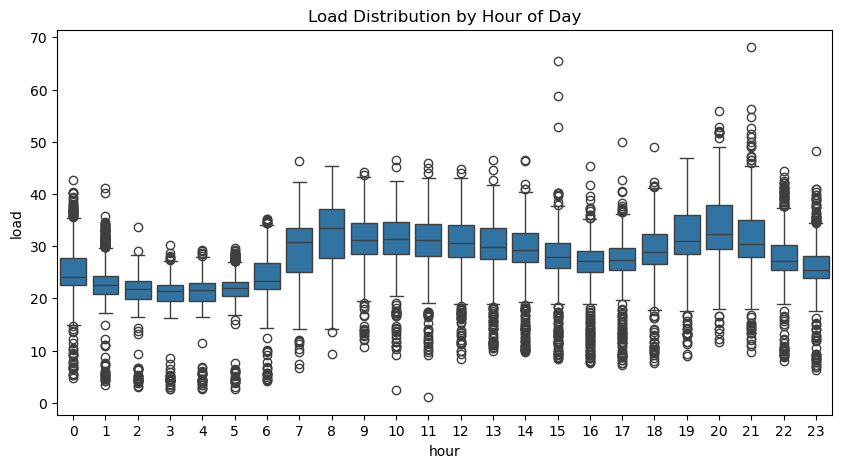

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='hour', y='load')
plt.title("Load Distribution by Hour of Day")
plt.show()

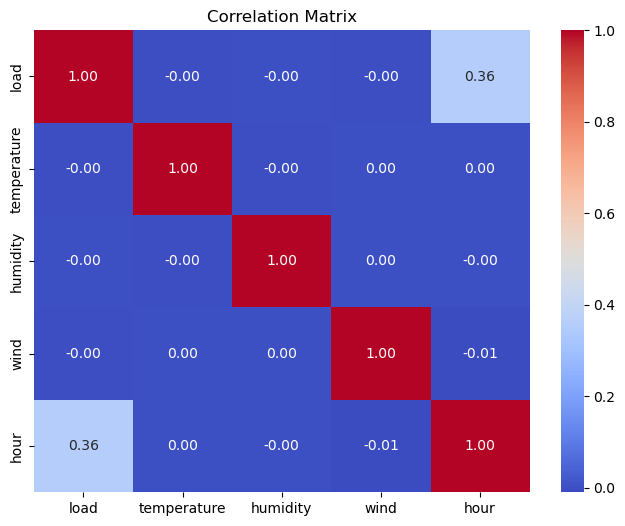

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [22]:
n = len(df)
train_df = df.iloc[:int(n*0.7)]
val_df = df.iloc[int(n*0.7):int(n*0.85)]
test_df = df.iloc[int(n*0.85):]

In [23]:
scaler = StandardScaler()
cols = ['load', 'temperature', 'humidity', 'wind']
scaler.fit(train_df[cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
def scale_data(data):
    sc_vals = scaler.transform(data[cols])
    sc_df = pd.DataFrame(sc_vals, columns=cols, index=data.index)
    sc_df['hour'] = data['hour'].values
    return sc_df

In [25]:
train_sc = scale_data(train_df)
val_sc = scale_data(val_df)
test_sc = scale_data(test_df)

In [26]:
def evaluate(y_true_sc, y_pred_sc):
    # Nghịch đảo để về đơn vị gốc
    dummy_t, dummy_p = np.zeros((len(y_true_sc), 4)), np.zeros((len(y_pred_sc), 4))
    dummy_t[:, 0], dummy_p[:, 0] = y_true_sc, y_pred_sc
    y_true = scaler.inverse_transform(dummy_t)[:, 0]
    y_pred = scaler.inverse_transform(dummy_p)[:, 0]
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape, y_true, y_pred

In [27]:
train_diff = train_sc[cols].diff().dropna()
model_var_init = VAR(train_diff)

In [ ]:
best_p = 1
min_val_mae = float('inf')
for p in range(1, 25):
    res = model_var_init.fit(p)
    val_forecast = res.forecast(train_sc[cols].values[-p:], steps=len(val_sc))
    mae = mean_absolute_error(val_sc['load'], val_forecast[:, 0])
    if mae < min_val_mae:
        min_val_mae = mae
        best_p = p

In [29]:
print(f"Lag p: {best_p}")
var_model = model_var_init.fit(best_p)

Lag p: 24


In [ ]:
history = val_sc[cols].values[-best_p:] 
var_preds = []
for i in range(len(test_sc)):
    forecast = var_model.forecast(history, steps=1)
    prev_val = test_sc.iloc[i-1, 0] if i > 0 else val_sc.iloc[-1, 0]
    var_preds.append(prev_val + forecast[0][0])
    history = np.vstack([history[1:], test_sc.iloc[i, :4].values])

In [31]:
rmse_v, mae_v, mape_v, y_test_v, y_pred_v = evaluate(test_sc['load'].values, np.array(var_preds))
acc_V = 100 - mape_v
print(f"VAR Final Metrics -> RMSE: {rmse_v:.2f}, MAE: {mae_v:.2f}, MAPE: {mape_v:.2f}%, Accuracy: {acc_V:.2f}%")

VAR Final Metrics -> RMSE: 19.94, MAE: 18.28, MAPE: 71.29%, Accuracy: 28.71%


In [32]:
def make_features(data):
    d = data.copy()
    for i in range(1, 25): d[f'lag_{i}'] = d['load'].shift(i)
    d['roll_mean_6h'] = d['load'].rolling(6).mean()
    d['roll_std_24h'] = d['load'].rolling(24).std()
    d['load_trend'] = d['load'] - d['load'].shift(24)
    return d

In [33]:
full_sc = make_features(pd.concat([train_sc, val_sc, test_sc])).dropna()
train_idx = full_sc.index.intersection(train_sc.index)
val_idx = full_sc.index.intersection(val_sc.index)
test_idx = full_sc.index.intersection(test_sc.index)

In [34]:
X_train, y_train = full_sc.loc[train_idx].drop(columns=['load']), full_sc.loc[train_idx]['load']
X_val, y_val = full_sc.loc[val_idx].drop(columns=['load']), full_sc.loc[val_idx]['load']
X_test, y_test_xg = full_sc.loc[test_idx].drop(columns=['load']), full_sc.loc[test_idx]['load']

In [35]:
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=10, early_stopping_rounds=50)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
xgb_preds = xgb_model.predict(X_test)
rmse_x, mae_x, mape_x, _, y_pred_x = evaluate(y_test_xg.values, xgb_preds)
acc_X = 100 - mape_x
print(f"XGBoost Results -> RMSE: {rmse_x:.2f}, MAE: {mae_x:.2f}, MAPE: {mape_x:.2f}%, Accuracy: {acc_X:.2f}%")

XGBoost Results -> RMSE: 0.47, MAE: 0.14, MAPE: 0.74%, Accuracy: 99.26%


In [37]:
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window]); y.append(data[i+window, 0])
    return torch.Tensor(X), torch.Tensor(y)

In [38]:
X_train_ls, y_train_ls = create_sequences(train_sc[cols].values)
X_val_ls, y_val_ls = create_sequences(val_sc[cols].values)
X_test_ls, y_test_ls = create_sequences(test_sc[cols].values)

In [ ]:
class LSTMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=4, hidden_size=64, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)
        
    def forward(self, x):
        # x: (batch, 24, 4)
        out, _ = self.lstm1(x) 
        out, _ = self.lstm2(out) 
        return self.fc(out[:, -1, :]) 

In [ ]:
model_ls = LSTMNet()
optimizer = torch.optim.Adam(model_ls.parameters(), lr=0.001) 
criterion = nn.MSELoss()

In [41]:
best_val_loss = float('inf')
for epoch in range(50):
    model_ls.train(); optimizer.zero_grad()
    outputs = model_ls(X_train_ls).squeeze()
    loss = criterion(outputs, y_train_ls); loss.backward(); optimizer.step()
    
    model_ls.eval()
    with torch.no_grad():
        v_out = model_ls(X_val_ls).squeeze()
        v_loss = criterion(v_out, y_val_ls)
    if epoch % 5 == 0: print(f"Epoch {epoch} | Train MSE: {loss.item():.4f} | Val MSE: {v_loss.item():.4f}")

Epoch 0 | Train MSE: 1.0135 | Val MSE: 0.7474
Epoch 5 | Train MSE: 0.9731 | Val MSE: 0.7564
Epoch 10 | Train MSE: 0.9361 | Val MSE: 0.7515
Epoch 15 | Train MSE: 0.8941 | Val MSE: 0.7010
Epoch 20 | Train MSE: 0.8476 | Val MSE: 0.6043
Epoch 25 | Train MSE: 0.8181 | Val MSE: 0.5391
Epoch 30 | Train MSE: 0.7948 | Val MSE: 0.5156
Epoch 35 | Train MSE: 0.7570 | Val MSE: 0.5079
Epoch 40 | Train MSE: 0.7175 | Val MSE: 0.4913
Epoch 45 | Train MSE: 0.6639 | Val MSE: 0.4419


In [ ]:
model_ls.eval()
with torch.no_grad():
    lstm_preds = model_ls(X_test_ls).numpy().flatten()

In [43]:
rmse_l, mae_l, mape_l, _, y_pred_l = evaluate(y_test_ls.numpy(), lstm_preds)
acc_L = 100 - mape_l
print(f"LSTM -> RMSE: {rmse_l:.2f}, MAE: {mae_l:.2f}, MAPE: {mape_l:.2f}%, Accuracy: {acc_L:.2f}%")

LSTM -> RMSE: 3.97, MAE: 3.17, MAPE: 13.29%, Accuracy: 86.71%


In [44]:
results = pd.DataFrame({
    'Model': ['VAR', 'XGBoost', 'LSTM'],
    'RMSE': [rmse_v, rmse_x, rmse_l],
    'MAE': [mae_v, mae_x, mae_l],
    'MAPE (%)': [mape_v, mape_x, mape_l],
    'Accuracy (%)': [acc_V, acc_X, acc_L]
})
print("\nMetrics")
print(results)


Metrics
     Model       RMSE        MAE   MAPE (%)  Accuracy (%)
0      VAR  19.940412  18.281749  71.293508     28.706492
1  XGBoost   0.472933   0.141522   0.737866     99.262134
2     LSTM   3.967316   3.169573  13.285674     86.714326


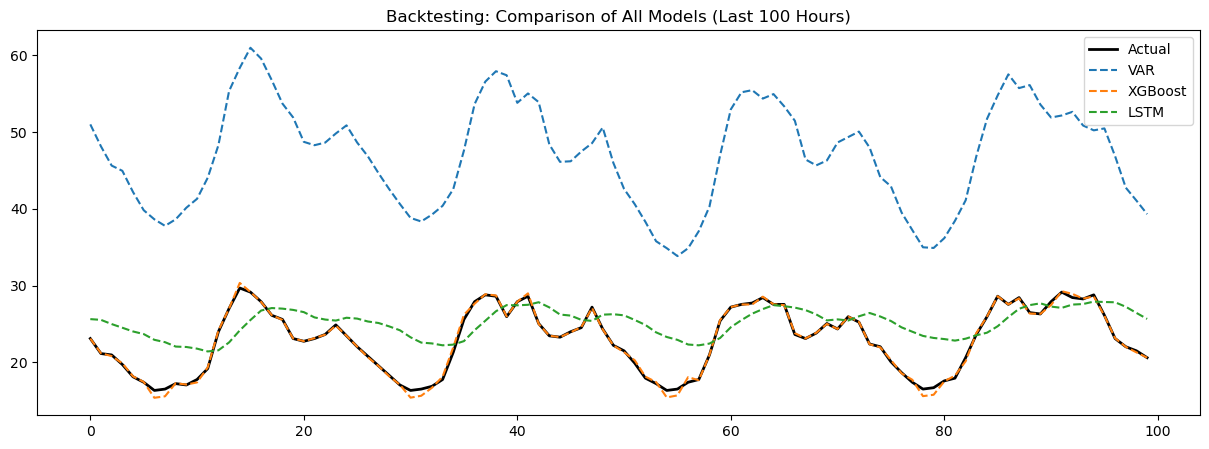

In [45]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_v[-100:], label='Actual', color='black', linewidth=2)
plt.plot(y_pred_v[-100:], label='VAR', linestyle='--')
plt.plot(y_pred_x[-100:], label='XGBoost', linestyle='--')
plt.plot(y_pred_l[-100:], label='LSTM', linestyle='--')
plt.title("Backtesting: Comparison of All Models (Last 100 Hours)")
plt.legend(); plt.show()